In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import eigh
from tqdm import tqdm
import sys
import os
import sympy as sp


# Add the parent directory to the path to import nmrkan modules
if os.path.abspath(os.path.join(os.getcwd(), '..')) not in sys.path:
    sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

# Import the Hamiltonian function
from data_generation.nmr_datagen import ham_reduced_symmetric
from nmrkan.utils.analytic2d import eigenvalues_ham_reduced_symmetric_ab
# Import training components from the unified framework
from nmrkan import KharKAN, SingleOutputTrainer, TrainingConfig, ModelConfig
import torch
from torch.utils.data import DataLoader, TensorDataset
from nmrkan.analysis import FormulaExtractor

# Set up plotting parameters
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("viridis")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
LIMIT = 2

# Helper to keep eigenvalues consistently ordered across sign flips
def sort_eigenvalues_with_flip(eigenvals, ratio_value=None, force_flip=False):
    ordered = np.sort(eigenvals)
    should_flip = force_flip or (ratio_value is not None and ratio_value < 0)
    if should_flip:
        ordered[[0, 2]] = ordered[[2, 0]]
    return ordered

In [3]:
# grid inputs of a nd b from -2 to 2 with 100 points each
a_values = np.linspace(-LIMIT, LIMIT, 200)
b_values = np.linspace(-LIMIT, LIMIT, 200)
A, B = np.meshgrid(a_values, b_values)
# compute eigenvalues for each (a, b) pair
eigenvalues_symbolic=eigenvalues_ham_reduced_symmetric_ab(A, B)
# and for each pair get the numerical eigenvalues from ham_reduced_symmetric
eigenvals_numerical = np.zeros((A.shape[0], A.shape[1], 4))
for i in tqdm(range(A.shape[0])):
    for j in range(A.shape[1]):
        deltajam_ratio = A[i, j]
        deltajmx_ratio = B[i, j]
        H = ham_reduced_symmetric(1.0, 1.0, 1.0, deltajam_ratio, deltajmx_ratio, 0.0)
        eigenvals, _ = eigh(H)
        eigenvals_numerical[i, j, :] = np.sort(eigenvals)


100%|██████████| 200/200 [00:00<00:00, 306.36it/s]


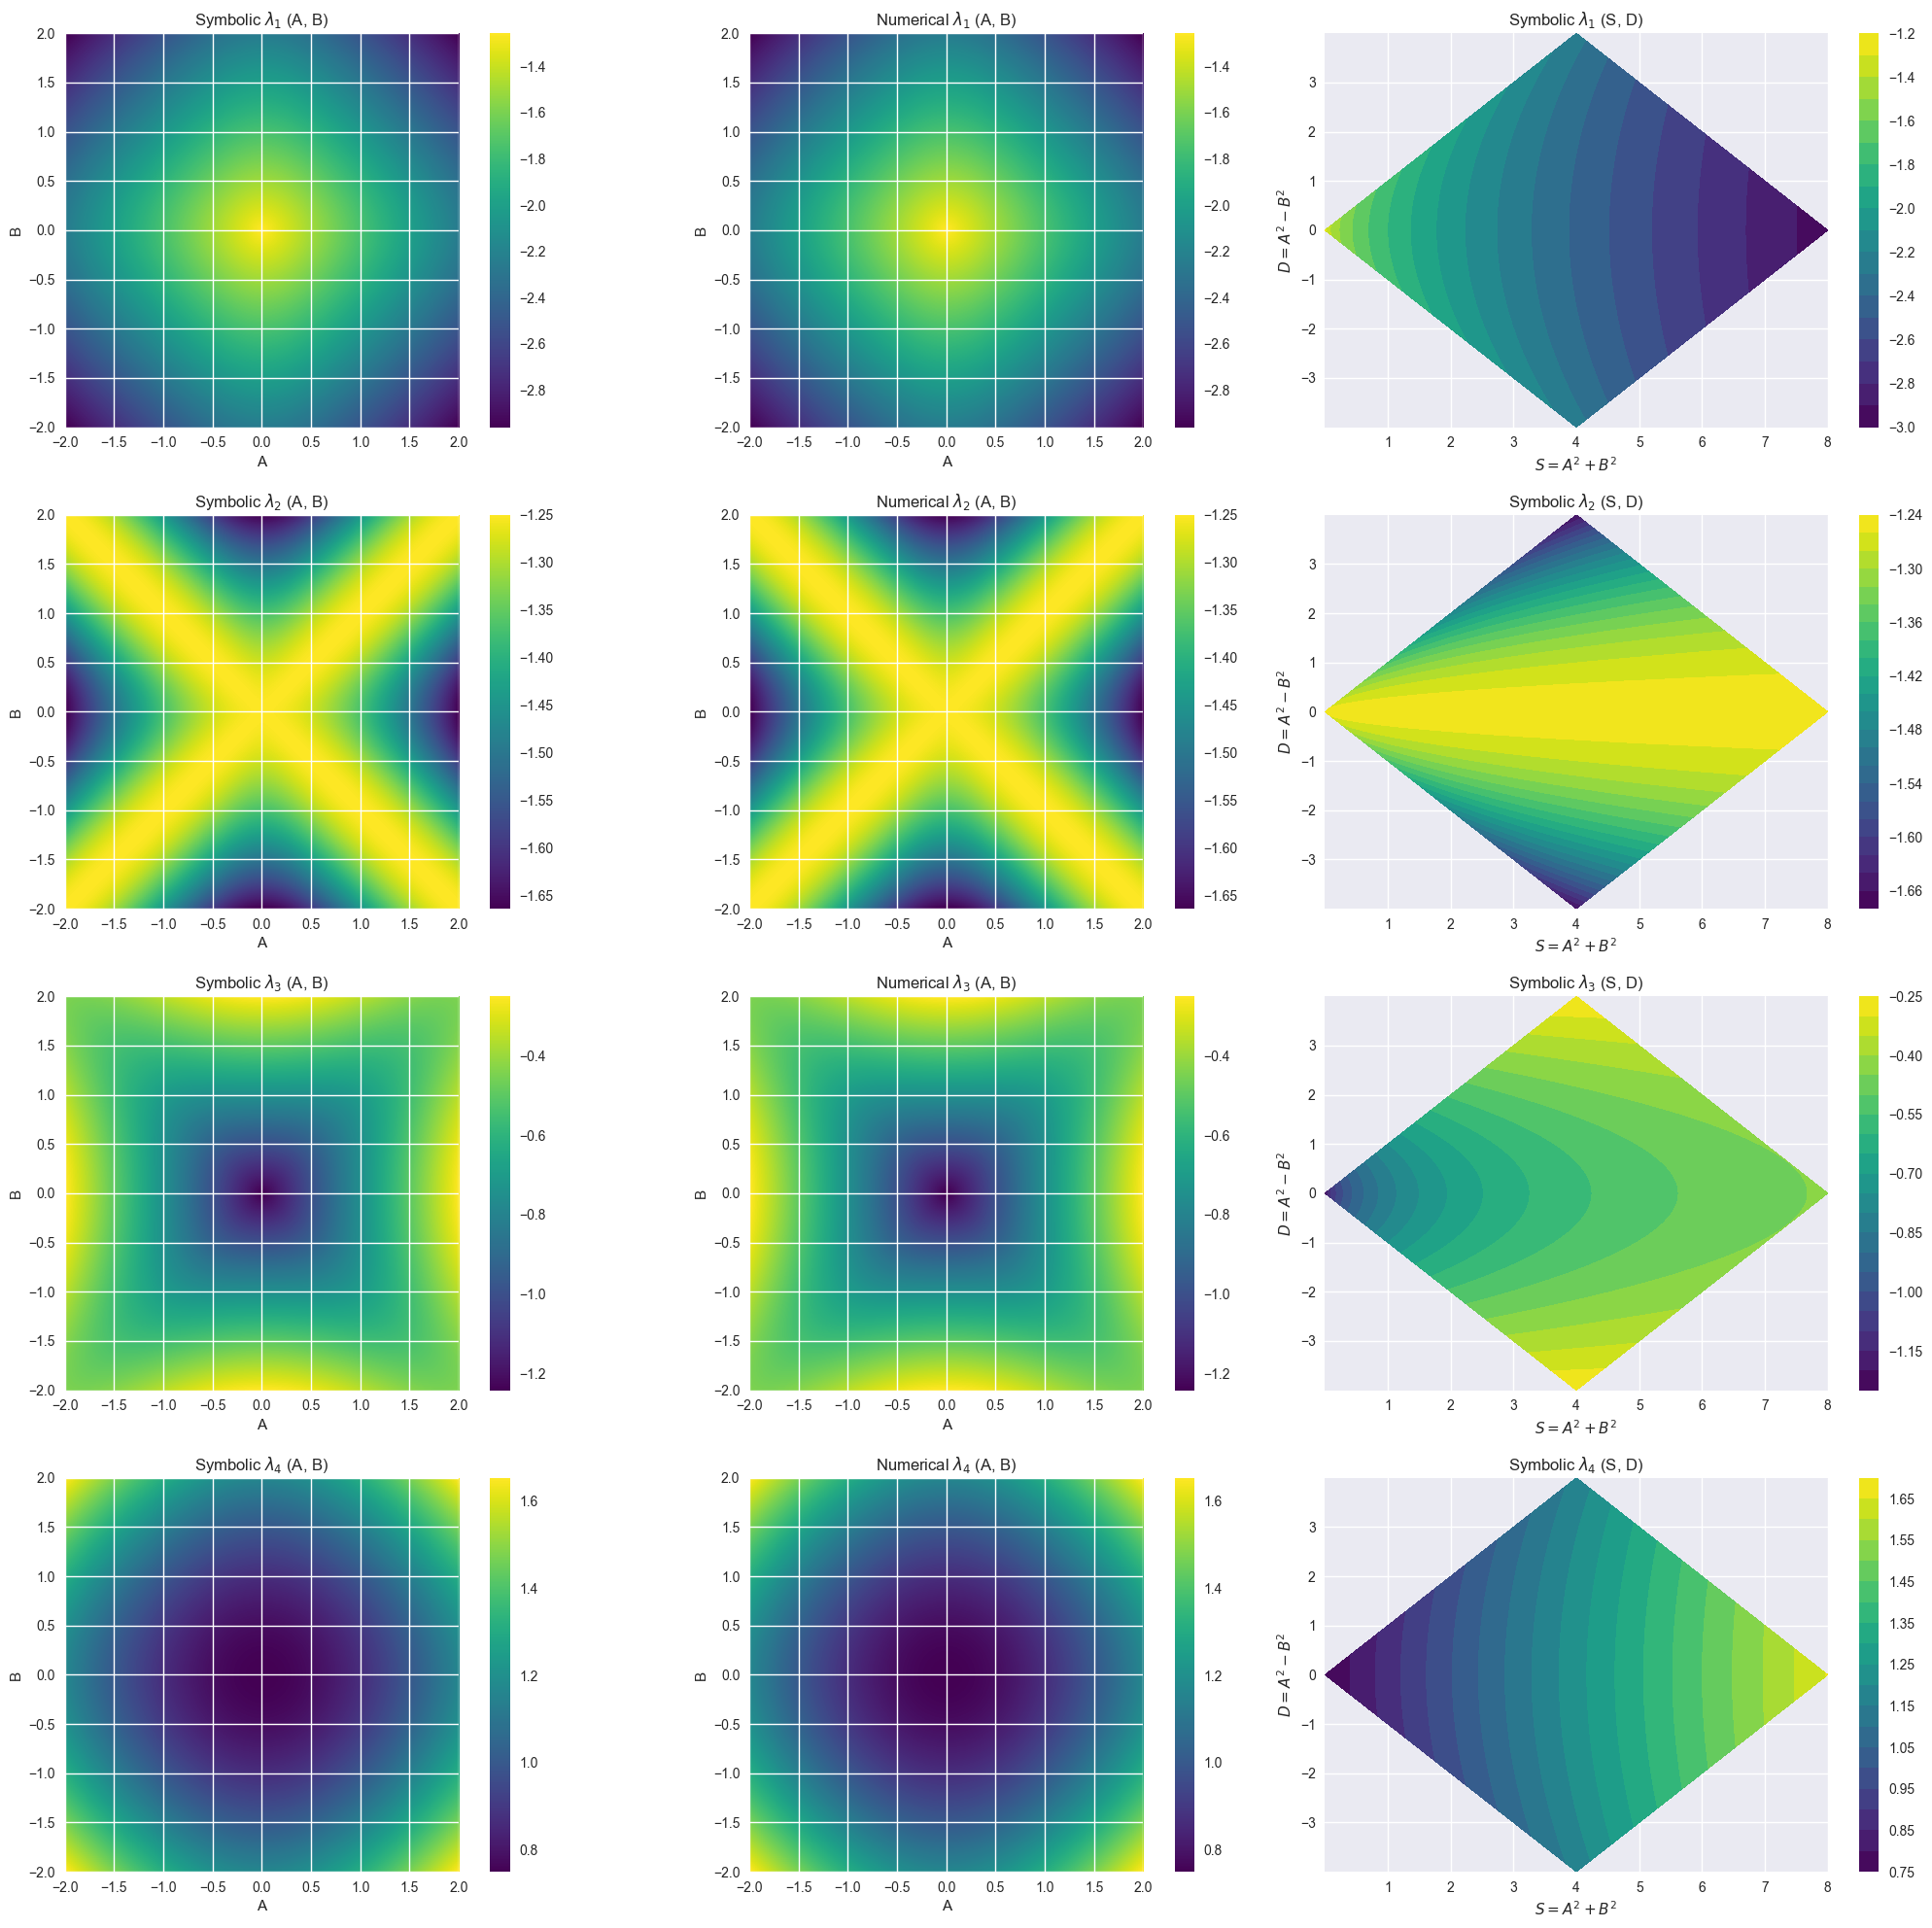

In [4]:
# Compare eigenvalues: Symbolic (A,B) | Numerical (A,B) | Symbolic (S,D)
S_grid = A**2 + B**2
D_grid = A**2 - B**2

fig, axs = plt.subplots(4, 3, figsize=(21, 20))
for idx in range(4):
    # Symbolic (A, B)
    im0 = axs[idx, 0].imshow(eigenvalues_symbolic[:, :, idx],
                              extent=(-LIMIT, LIMIT, -LIMIT, LIMIT), origin='lower', cmap='viridis')
    axs[idx, 0].set_title(f'Symbolic $\\lambda_{idx+1}$ (A, B)')
    axs[idx, 0].set_xlabel('A'); axs[idx, 0].set_ylabel('B')
    fig.colorbar(im0, ax=axs[idx, 0])

    # Numerical (A, B)
    im1 = axs[idx, 1].imshow(eigenvals_numerical[:, :, idx],
                              extent=(-LIMIT, LIMIT, -LIMIT, LIMIT), origin='lower', cmap='viridis')
    axs[idx, 1].set_title(f'Numerical $\\lambda_{idx+1}$ (A, B)')
    axs[idx, 1].set_xlabel('A'); axs[idx, 1].set_ylabel('B')
    fig.colorbar(im1, ax=axs[idx, 1])

    # Symbolic in (S, D) coordinates — filled contour from irregular grid
    tc = axs[idx, 2].tricontourf(S_grid.flatten(), D_grid.flatten(),
                                  eigenvalues_symbolic[:, :, idx].flatten(),
                                  levels=20, cmap='viridis')
    axs[idx, 2].set_title(f'Symbolic $\\lambda_{idx+1}$ (S, D)')
    axs[idx, 2].set_xlabel(r'$S = A^2 + B^2$'); axs[idx, 2].set_ylabel(r'$D = A^2 - B^2$')
    fig.colorbar(tc, ax=axs[idx, 2])

plt.tight_layout()

In [5]:
# Generate 2D dataset and compute (S, D) coordinates
def generate_2d_normalized_dataset(n_samples=50000,
                                   deltajam_ratio_range=(-LIMIT, LIMIT),
                                   deltajmx_ratio_range=(-LIMIT, LIMIT)):
    np.random.seed(42)
    deltajam_ratios = np.random.uniform(*deltajam_ratio_range, n_samples)
    deltajmx_ratios = np.random.uniform(*deltajmx_ratio_range, n_samples)

    inputs = np.zeros((n_samples, 2))
    eigenvals_out = np.zeros((n_samples, 4))
    ok = 0
    for i in tqdm(range(n_samples), desc="Generating 2D dataset"):
        try:
            H = ham_reduced_symmetric(1.0, 1.0, 1.0, deltajam_ratios[i], deltajmx_ratios[i], 0.0)
            eigenvals, _ = eigh(H)
            eigenvals = sort_eigenvalues_with_flip(eigenvals, ratio_value=1)
            inputs[ok] = [deltajam_ratios[i], deltajmx_ratios[i]]
            eigenvals_out[ok] = eigenvals
            ok += 1
        except Exception:
            continue
    return inputs[:ok], eigenvals_out[:ok]

X, y = generate_2d_normalized_dataset(100000)

# Coordinate transformation: A, B -> S = A² + B², D = A² - B²
# Motivated by quartic: p = -(S+3)/2, q = -1, r = D²/16 + S/8 - 3/16
S_data = X[:, 0]**2 + X[:, 1]**2
D_data = X[:, 0]**2 - X[:, 1]**2
X_sd = np.column_stack([S_data, D_data])

print(f"Dataset: {X.shape[0]} samples")
print(f"  A ∈ [{X[:,0].min():.2f}, {X[:,0].max():.2f}],  B ∈ [{X[:,1].min():.2f}, {X[:,1].max():.2f}]")
print(f"  S = A²+B² ∈ [{S_data.min():.3f}, {S_data.max():.3f}]")
print(f"  D = A²-B² ∈ [{D_data.min():.3f}, {D_data.max():.3f}]  (constraint: |D| ≤ S)")

Generating 2D dataset: 100%|██████████| 100000/100000 [00:01<00:00, 59087.31it/s]

Dataset: 100000 samples
  A ∈ [-2.00, 2.00],  B ∈ [-2.00, 2.00]
  S = A²+B² ∈ [0.000, 7.923]
  D = A²-B² ∈ [-3.996, 3.995]  (constraint: |D| ≤ S)


Grid rows: 100%|██████████| 50/50 [00:00<00:00, 1194.97it/s]


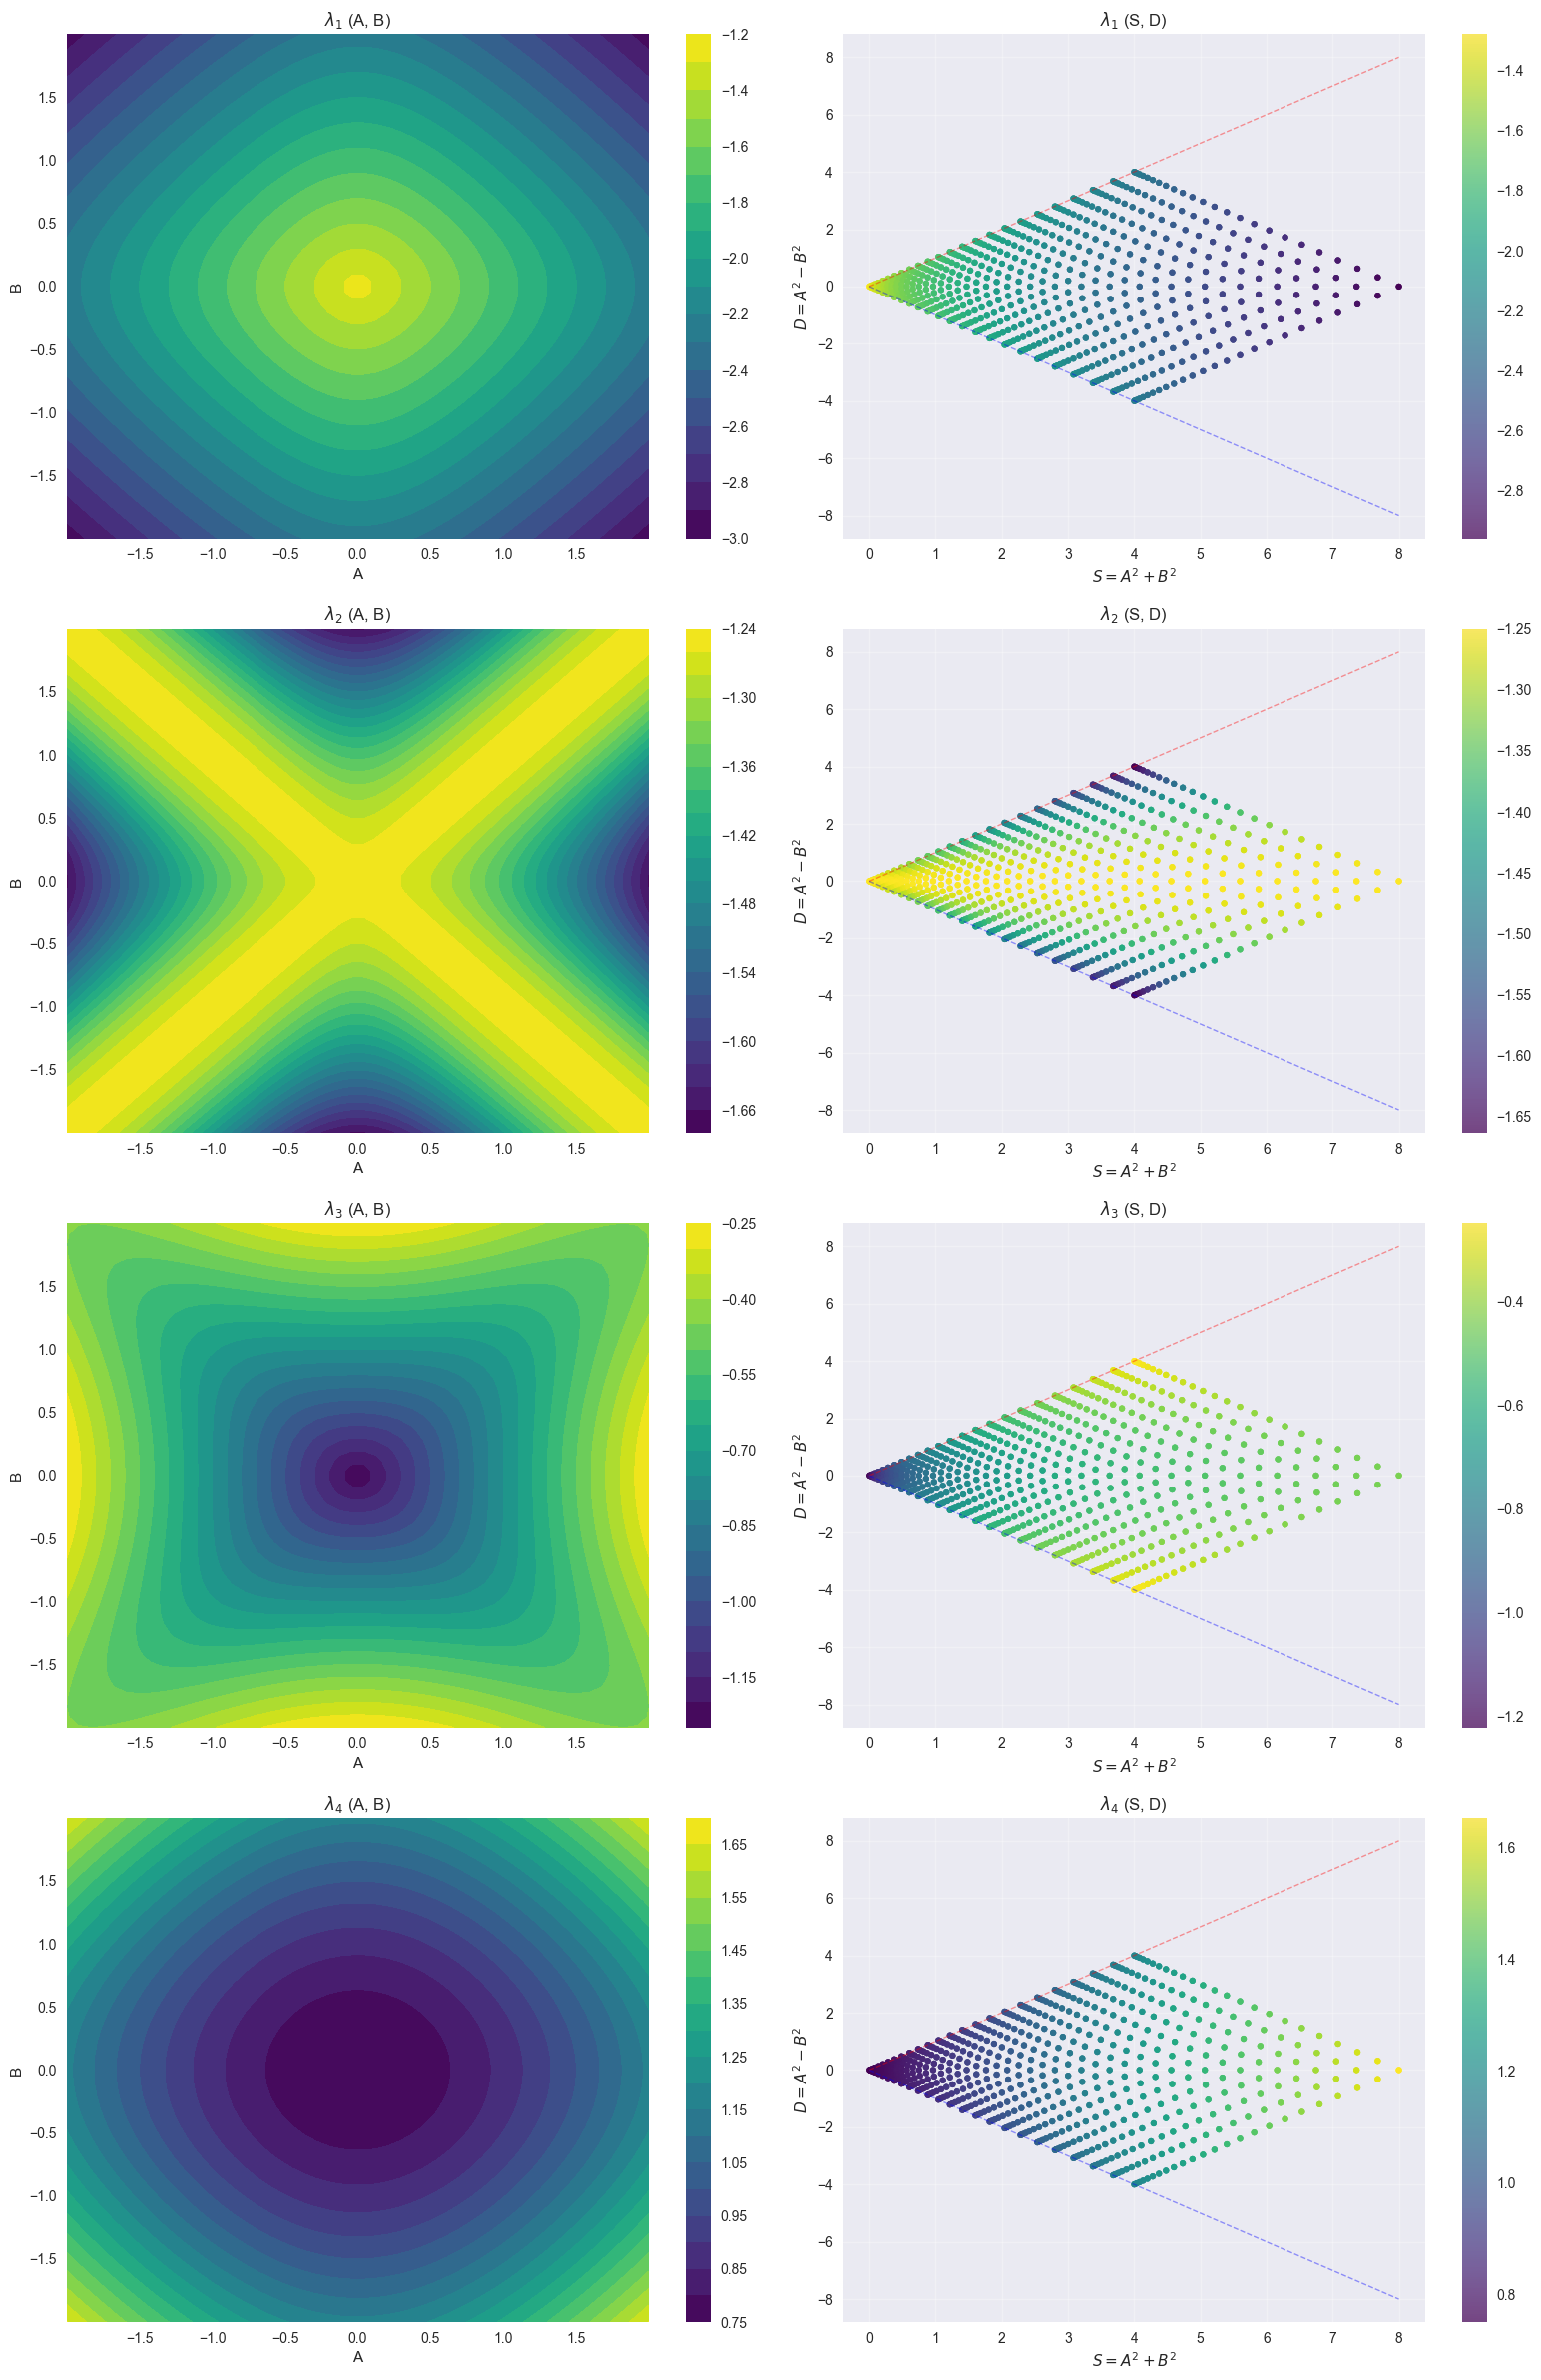

In [6]:
# Eigenvalue surfaces on regular grid — (A,B) contour | (S,D) scatter
n_grid = 50
x1_grid = np.linspace(X[:, 0].min(), X[:, 0].max(), n_grid)
x2_grid = np.linspace(X[:, 1].min(), X[:, 1].max(), n_grid)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

eigenval_surfaces = np.zeros((n_grid, n_grid, 4))
for i in tqdm(range(n_grid), desc="Grid rows"):
    for j in range(n_grid):
        try:
            H = ham_reduced_symmetric(1.0, 1.0, 1.0, X1_grid[i, j], X2_grid[i, j], 0.0)
            eigenvals, _ = eigh(H)
            eigenval_surfaces[i, j, :] = sort_eigenvalues_with_flip(eigenvals, ratio_value=1)
        except:
            eigenval_surfaces[i, j, :] = np.nan

S_surf = X1_grid**2 + X2_grid**2
D_surf = X1_grid**2 - X2_grid**2

fig, axes = plt.subplots(4, 2, figsize=(16, 24))
for i in range(4):
    # (A, B) contour
    im = axes[i, 0].contourf(X1_grid, X2_grid, eigenval_surfaces[:, :, i], levels=20, cmap='viridis')
    axes[i, 0].set(title=f'$\\lambda_{i+1}$ (A, B)', xlabel='A', ylabel='B')
    axes[i, 0].grid(True, alpha=0.3)
    plt.colorbar(im, ax=axes[i, 0])

    # (S, D) scatter
    sc = axes[i, 1].scatter(S_surf.flatten(), D_surf.flatten(),
                           c=eigenval_surfaces[:, :, i].flatten(),
                           cmap='viridis', s=20, alpha=0.7, edgecolors='none')
    s_line = np.linspace(0, S_surf.max(), 100)
    axes[i, 1].plot(s_line, s_line, 'r--', alpha=0.4, lw=1)
    axes[i, 1].plot(s_line, -s_line, 'b--', alpha=0.4, lw=1)
    axes[i, 1].set(title=f'$\\lambda_{i+1}$ (S, D)', xlabel=r'$S = A^2+B^2$', ylabel=r'$D = A^2-B^2$')
    axes[i, 1].grid(True, alpha=0.3)
    plt.colorbar(sc, ax=axes[i, 1])

plt.tight_layout()

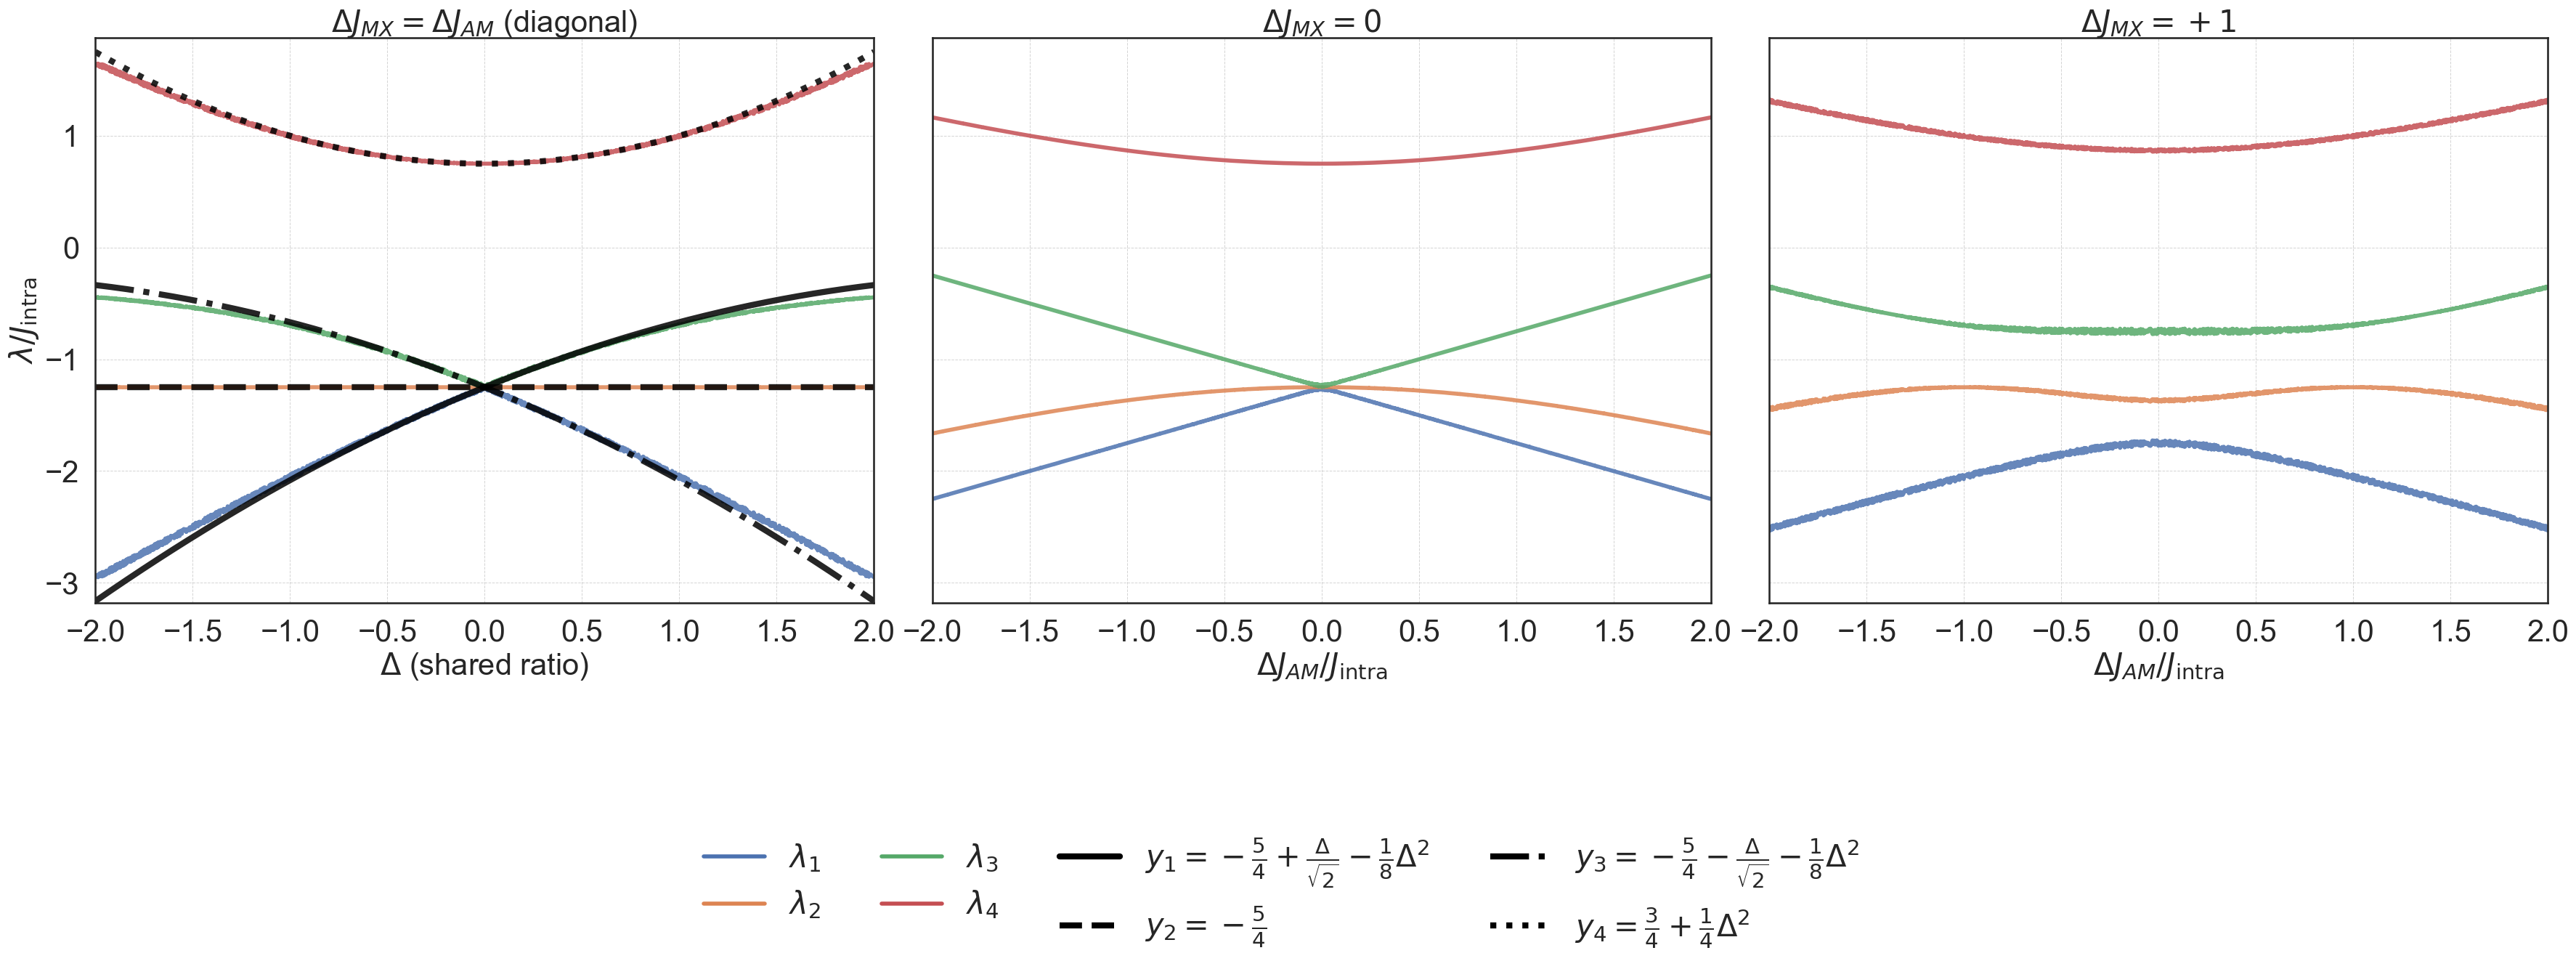

1D cross-section plot saved to: c:\Projects\NMRKan\notebooks\kan_1d_cross_sections.pdf


In [7]:
# 1D cross sections with updated ΔJMX labeling (Seaborn-enhanced aesthetics)
ratio_jam = X[:, 0]
ratio_jmx = X[:, 1]
eigenval_series = y.T
tolerance = 0.05

from matplotlib.lines import Line2D

y_min = np.min(eigenval_series)
y_max = np.max(eigenval_series)
y_padding = 0.05 * (y_max - y_min)
y_limits = (y_min - y_padding, y_max + y_padding)

sections = [
    {
        "title": r"$\Delta J_{MX} = \Delta J_{AM}$ (diagonal)",
        "mask": np.abs(ratio_jmx - ratio_jam) < tolerance,
        "x_data": ratio_jam,
        "xlabel": r"$\Delta$ (shared ratio)",
        "include_analytic": True
    },
    {
        "title": r"$\Delta J_{MX} = 0$",
        "mask": np.abs(ratio_jmx - 0.0) < tolerance,
        "x_data": ratio_jam,
        "xlabel": r"$\Delta J_{AM} / J_{\text{intra}}$"
    },
    {
        "title": r"$\Delta J_{MX} = +1$",
        "mask": np.abs(ratio_jmx - 1.0) < tolerance,
        "x_data": ratio_jam,
        "xlabel": r"$\Delta J_{AM} / J_{\text{intra}}$"
    }
]

sns.set_theme(context='talk', style='white')

with plt.rc_context({
    'font.size': 30,
    'axes.titlesize': 30,
    'axes.labelsize': 30,
    'xtick.labelsize': 30,
    'ytick.labelsize': 30,
    'legend.fontsize': 30
}):
    fig, axes = plt.subplots(1, len(sections), figsize=(36, 12), sharey=True)
    axes = np.atleast_1d(axes)

    colors = sns.color_palette('deep', 4)
    labels = [
        r"$\lambda_1$", r"$\lambda_2$", r"$\lambda_3$", r"$\lambda_4$"
    ]

    fig.patch.set_facecolor('white')
    
    # Collect handles for global legend
    scatter_handles = []
    analytic_handles = []

    for idx, (ax, section) in enumerate(zip(axes, sections)):
        mask = section["mask"]
        ax.set_facecolor('white')
        ax.grid(True, color='#d0d0d0', linestyle='--', linewidth=0.7, alpha=0.9)
        ax.set_xlim(-LIMIT, LIMIT)
        ax.set_ylim(*y_limits)

        if not np.any(mask):
            ax.text(0.5, 0.5, 'No samples in slice', transform=ax.transAxes,
                    ha='center', va='center', fontsize=30)
            ax.set_title(section["title"])
            ax.set_xlabel(section["xlabel"])
            ax.set_ylabel(r"$\lambda / J_{\text{intra}}$")
            continue

        x_vals = section["x_data"][mask]

        # Create line plots and collect handles only once
        for ev, color, label in zip(eigenval_series, colors, labels):
            # Sort data by x_vals for proper line plotting
            y_vals = ev[mask]
            sort_indices = np.argsort(x_vals)
            x_sorted = x_vals[sort_indices]
            y_sorted = y_vals[sort_indices]
            
            ax.plot(x_sorted, y_sorted, color=color, linewidth=4, alpha=0.85)
            if idx == 0:  # Collect handles only from first subplot
                scatter_handles.append(
                    Line2D([0], [0], color=color, linewidth=4, label=label)
                )

        # Create analytic curves and collect handles only once
        if section.get("include_analytic") and idx == 0:
            delta_plot = np.linspace(-2, 2, 400)
            analytic_curves = [
                (-1.25 + delta_plot / np.sqrt(2) - 0.125 * delta_plot**2,
                 r"$y_1 = -\frac{5}{4} + \frac{\Delta}{\sqrt{2}} - \frac{1}{8}\Delta^2$"),
                (-1.25 * np.ones_like(delta_plot),
                 r"$y_2 = -\frac{5}{4}$"),
                (-1.25 - delta_plot / np.sqrt(2) - 0.125 * delta_plot**2,
                 r"$y_3 = -\frac{5}{4} - \frac{\Delta}{\sqrt{2}} - \frac{1}{8}\Delta^2$"),
                (0.75 + 0.25 * delta_plot**2,
                 r"$y_4 = \frac{3}{4} + \frac{1}{4}\Delta^2$")
            ]
            line_styles = ['-', '--', '-.', ':']
            for (curve, curve_label), style in zip(analytic_curves, line_styles):
                ax.plot(delta_plot, curve, linestyle=style, linewidth=6,
                        color='black', alpha=0.85)
                analytic_handles.append(
                    Line2D([0], [0], linestyle=style, color='black', linewidth=6, label=curve_label)
                )
        elif section.get("include_analytic"):
            # Plot analytic curves without collecting handles
            delta_plot = np.linspace(-2, 2, 400)
            analytic_curves = [
                (-1.25 + delta_plot / np.sqrt(2) - 0.125 * delta_plot**2,),
                (-1.25 * np.ones_like(delta_plot),),
                (-1.25 - delta_plot / np.sqrt(2) - 0.125 * delta_plot**2,),
                (0.75 + 0.25 * delta_plot**2,)
            ]
            line_styles = ['-', '--', '-.', ':']
            for curve, style in zip(analytic_curves, line_styles):
                ax.plot(delta_plot, curve[0], linestyle=style, linewidth=3,
                        color='black', alpha=0.85)

        ax.set_title(section["title"])
        ax.set_xlabel(section["xlabel"])
        if idx == 0:
            ax.set_ylabel(r"$\lambda / J_{\text{intra}}$")
        ax.tick_params(axis='both', which='major', labelsize=30)

    # Create figure-level legend below the plots
    all_handles = scatter_handles + analytic_handles
    all_labels = [h.get_label() for h in all_handles]
    
    fig.legend(all_handles, all_labels, 
               loc='lower center', bbox_to_anchor=(0.5, -0.15),
               ncol=4, frameon=False, fontsize=30)

    plt.tight_layout(rect=[0, 0.15, 1, 1])
    output_path = os.path.join(os.getcwd(), 'kan_1d_cross_sections.pdf')
    plt.savefig(output_path, dpi=600, bbox_inches='tight')
    plt.show()

print(f"1D cross-section plot saved to: {output_path}")

# Train 2D KAN Model in New Coordinates (S, D)

We train a KAN model with 2 inputs in the **new coordinate system**:
- $S = A^2 + B^2$ (sum of squares)
- $D = A^2 - B^2$ (difference of squares)

to predict the 4 normalized eigenvalues. This coordinate change is motivated by the analytic structure of the quartic equation, where the depressed quartic coefficients are:
- $p = -(S + 3)/2$
- $q = -1$ (constant!)  
- $r = D^2/16 + S/8 - 3/16$

So eigenvalues are naturally functions of $S$ and $D$ rather than $A$ and $B$ individually.

In [8]:
# Prepare data, configure model, create loaders
device = 'cuda' if torch.cuda.is_available() else 'cpu'

X_tensor = torch.tensor(X_sd, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)

model_config = ModelConfig(
    layers=(2, 16, 4, 4),
    linear_bias=True,
    include_abs=False,
)

training_config = TrainingConfig(
    epochs=100,
    learning_rate=1e-3,
    batch_size=2048,
    l05_penalty=0.1,
    early_stopping_threshold=1e-6,
    early_stopping_patience=800,
    log_interval=1000,
)

dataset_tensor = TensorDataset(X_tensor, y_tensor)
train_size = int(0.8 * len(dataset_tensor))
val_size = len(dataset_tensor) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    dataset_tensor, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_dataset, batch_size=training_config.batch_size, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=training_config.batch_size, shuffle=False)

print(f"Device: {device}")
print(f"Inputs: {X_tensor.shape} (S = A²+B², D = A²-B²) → Outputs: {y_tensor.shape}")
print(f"Architecture: {model_config.layers},  Train/Val: {train_size}/{val_size}")

Device: cuda
Inputs: torch.Size([100000, 2]) (S = A²+B², D = A²-B²) → Outputs: torch.Size([100000, 4])
Architecture: (2, 16, 4, 4),  Train/Val: 80000/20000


In [9]:
# Initialize and train the 2D KAN model
trainer = SingleOutputTrainer(
    training_config=training_config,
    model_config=model_config,
    device=device,
    experiment_dir=None  # Don't save checkpoints in notebook
)

print("Starting 2D KAN training...")
print("=" * 60)
trainer.training_config.epochs=1000
# Train the model
kan_2d_model = trainer.train(train_loader, val_loader)

print("=" * 60)
print("2D KAN training completed!")

Starting 2D KAN training...
Starting single output training...
Model architecture: (2, 16, 4, 4)
Training on device: cuda


Training:   0%|          | 1/1000 [00:00<15:28,  1.08it/s, Train MSE=4.785725, Val MSE=2.028363, Best Val=2.028363]

Epoch 1: MSE=4.785725, L0.5=16.104292, Total=6.396154


Training: 100%|██████████| 1000/1000 [21:31<00:00,  1.29s/it, Train MSE=0.000865, Val MSE=0.001069, Best Val=0.000821]


Epoch 1000: MSE=0.000865, L0.5=0.007480, Total=0.001613
Training plots saved to: experiment_results\unified_experiments_1771147138\training_curves.png

Training completed! Best validation MSE: 0.000821
Results saved to: experiment_results\unified_experiments_1771147138
2D KAN training completed!


MSE: 0.001075,  MAE: 0.021471,  Avg R²: 0.9513
  λ1 R²: 0.9933
  λ2 R²: 0.8608
  λ3 R²: 0.9515
  λ4 R²: 0.9996


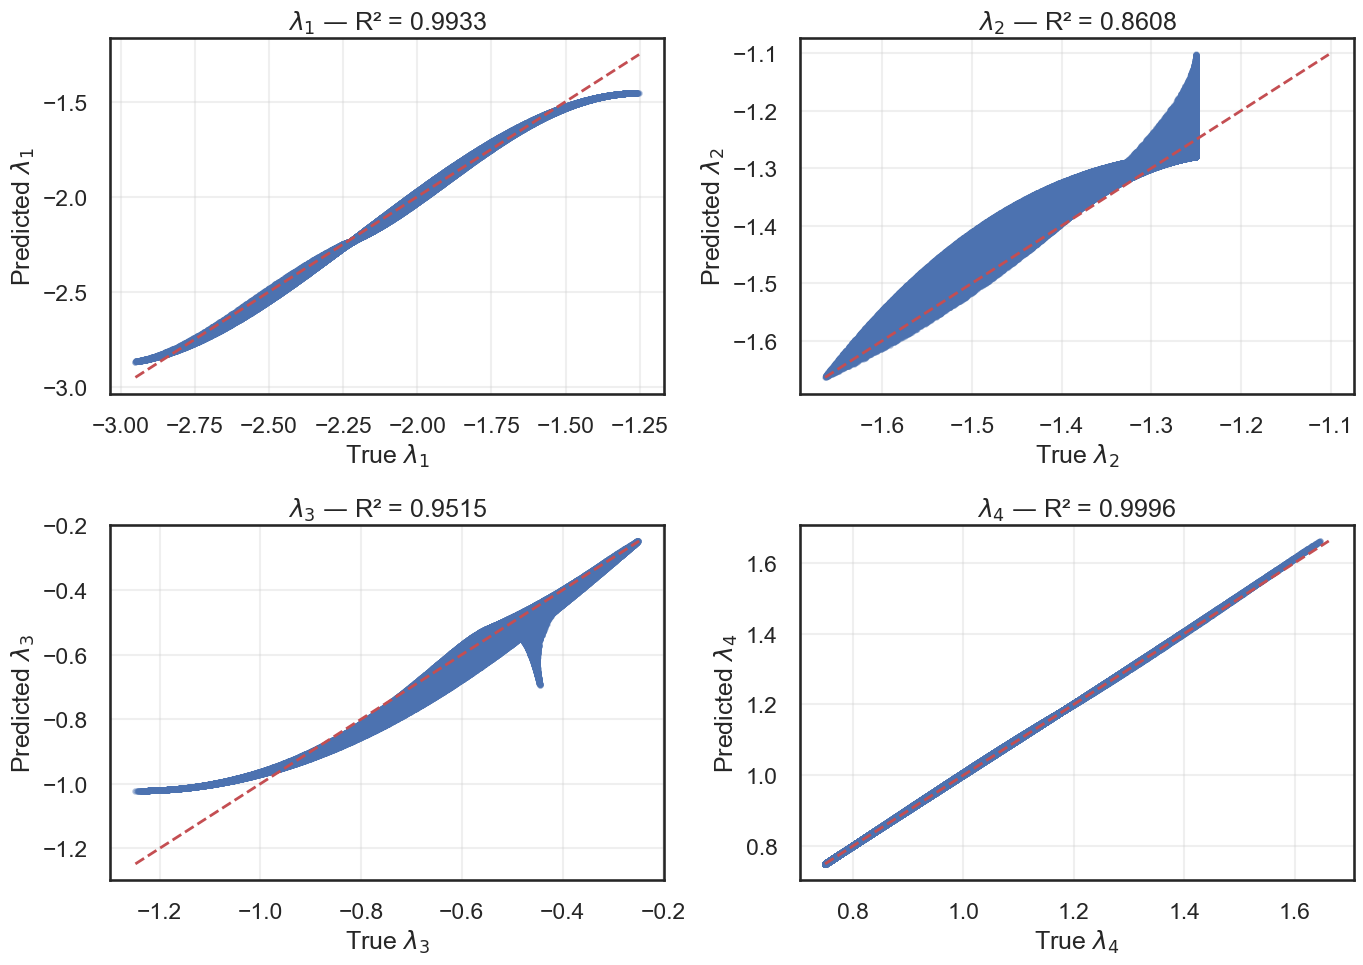

In [10]:
# Evaluate model and plot predictions vs true
kan_2d_model.eval()
with torch.no_grad():
    y_pred_2d = kan_2d_model(X_tensor.to(device)).cpu().numpy()
    y_true_2d = y_tensor.numpy()

mse_2d = np.mean((y_pred_2d - y_true_2d)**2)
r2_scores_2d = []
for i in range(4):
    ss_res = np.sum((y_true_2d[:, i] - y_pred_2d[:, i]) ** 2)
    ss_tot = np.sum((y_true_2d[:, i] - np.mean(y_true_2d[:, i])) ** 2)
    r2_scores_2d.append(1 - ss_res / ss_tot)

print(f"MSE: {mse_2d:.6f},  MAE: {np.mean(np.abs(y_pred_2d - y_true_2d)):.6f},  Avg R²: {np.mean(r2_scores_2d):.4f}")
for i, r2 in enumerate(r2_scores_2d):
    print(f"  λ{i+1} R²: {r2:.4f}")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, ax in enumerate(axes.flatten()):
    ax.scatter(y_true_2d[:, i], y_pred_2d[:, i], alpha=0.4, s=10)
    lims = [min(y_true_2d[:, i].min(), y_pred_2d[:, i].min()),
            max(y_true_2d[:, i].max(), y_pred_2d[:, i].max())]
    ax.plot(lims, lims, 'r--', linewidth=2)
    ax.set(xlabel=f'True $\\lambda_{i+1}$', ylabel=f'Predicted $\\lambda_{i+1}$',
           title=f'$\\lambda_{i+1}$ — R² = {r2_scores_2d[i]:.4f}')
    ax.grid(True, alpha=0.3)
plt.tight_layout()

Text(0.5, 1.01, 'True (A,B)  |  Predicted (A,B)  |  Error (S,D)')

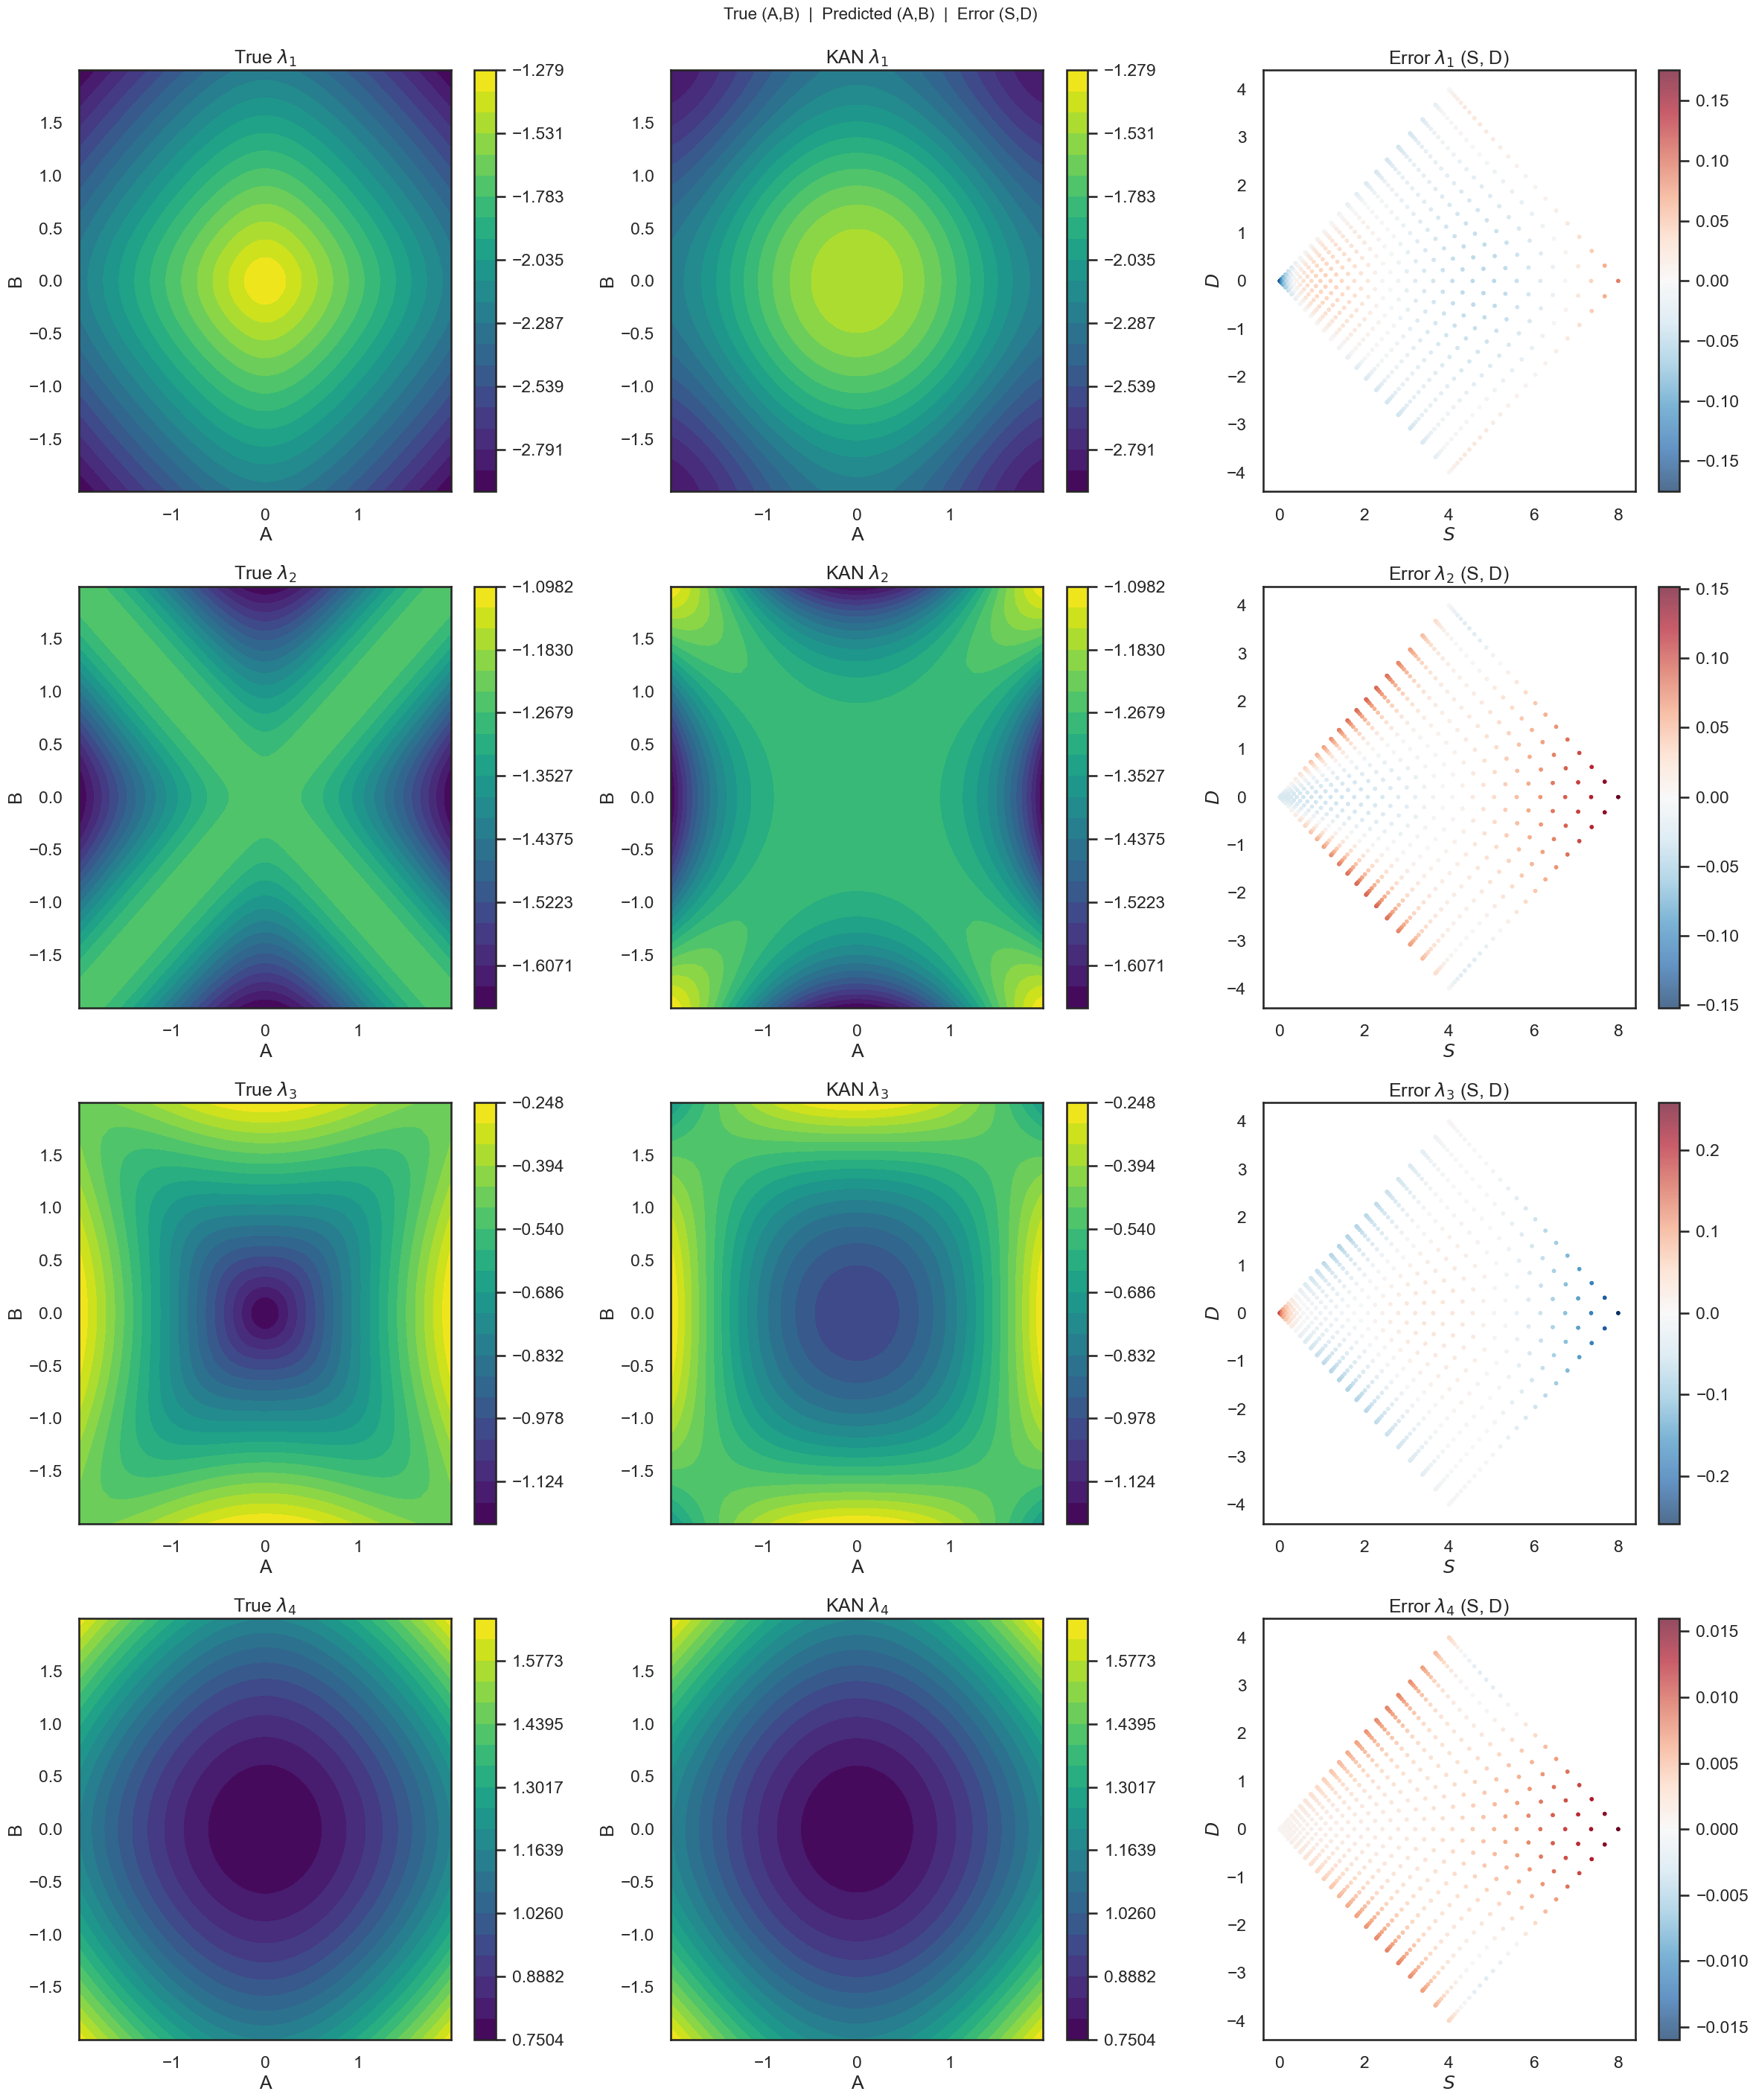

In [11]:
# Prediction surfaces: True (A,B) | Predicted (A,B) | Error (S,D)
grid_sd_tensor = torch.tensor(
    np.column_stack([S_surf.flatten(), D_surf.flatten()]), dtype=torch.float32
).to(device)

with torch.no_grad():
    pred_surfaces = kan_2d_model(grid_sd_tensor).cpu().numpy().reshape(n_grid, n_grid, 4)

fig, axes = plt.subplots(4, 3, figsize=(24, 28))
for i in range(4):
    # Shared levels for true and predicted
    vmin = min(eigenval_surfaces[:, :, i].min(), pred_surfaces[:, :, i].min())
    vmax = max(eigenval_surfaces[:, :, i].max(), pred_surfaces[:, :, i].max())
    levels = np.linspace(vmin, vmax, 21)

    # True (A, B)
    im1 = axes[i, 0].contourf(X1_grid, X2_grid, eigenval_surfaces[:, :, i], levels=levels, cmap='viridis')
    axes[i, 0].set(title=f'True $\\lambda_{i+1}$', xlabel='A', ylabel='B')
    plt.colorbar(im1, ax=axes[i, 0])

    # Predicted (A, B)
    im2 = axes[i, 1].contourf(X1_grid, X2_grid, pred_surfaces[:, :, i], levels=levels, cmap='viridis')
    axes[i, 1].set(title=f'KAN $\\lambda_{i+1}$', xlabel='A', ylabel='B')
    plt.colorbar(im2, ax=axes[i, 1])

    # Error in (S, D)
    error = pred_surfaces[:, :, i] - eigenval_surfaces[:, :, i]
    emax = np.max(np.abs(error))
    sc = axes[i, 2].scatter(S_surf.flatten(), D_surf.flatten(),
                            c=error.flatten(), cmap='RdBu_r', s=15, alpha=0.7,
                            edgecolors='none', vmin=-emax, vmax=emax)
    axes[i, 2].set(title=f'Error $\\lambda_{i+1}$ (S, D)', xlabel=r'$S$', ylabel=r'$D$')
    plt.colorbar(sc, ax=axes[i, 2])

plt.tight_layout()
plt.suptitle('True (A,B)  |  Predicted (A,B)  |  Error (S,D)', fontsize=16, y=1.01)

In [12]:
# Extract symbolic formulas from the 2D KAN model in (S, D) coordinates
formula_extractor_2d = FormulaExtractor(
    models=kan_2d_model,
    input_names=['S', 'D'],
    output_names=[f'eigenval_{i+1}' for i in range(4)]
)

# Extract formulas
print("Extracting symbolic formulas from 2D KAN model")
print("Coordinates: S = A² + B², D = A² - B²")
print()
formulas_2d = formula_extractor_2d.extract_formulas(clean=True, round_digits=3)

# Display the formulas
print("2D KAN Symbolic Formulas in (S, D) coordinates:")
print("=" * 80)

for model_key, model_formulas in formulas_2d.items():
    for output_name, expr in model_formulas.items():
        print(f"{output_name}: {expr}")
        print()

# Calculate complexity metrics
complexity_2d = formula_extractor_2d.calculate_complexity(formulas_2d)

print("2D Formula Complexity Metrics:")
print("=" * 80)
for model_key, model_metrics in complexity_2d.items():
    for output_name, metrics in model_metrics.items():
        print(f"{output_name}:")
        print(f"  Terms: {metrics['num_terms']}")
        print(f"  Operations: {metrics['num_operations']}")
        print(f"  Max Degree: {metrics['max_degree']}")
        print(f"  Variables: {metrics['num_variables']}")
        print()

# Compare with expected analytic structure
print("Expected analytic dependence (from quartic equation):")
print("  p = -(S + 3)/2")
print("  q = -1  (constant)")
print("  r = D²/16 + S/8 - 3/16")
print("  eigenvalues = f(S, D²) with shift -3/4")

Extracting symbolic formulas from 2D KAN model
Coordinates: S = A² + B², D = A² - B²

2D KAN Symbolic Formulas in (S, D) coordinates:
eigenval_1: 0.005*D**2 + 0.019*S**2 - 0.327*S - 1.453

eigenval_2: -0.015*D**2 + 0.004*S**2 - 0.009*S - 1.274

eigenval_3: 0.012*D**2 - 0.021*S**2 + 0.206*S - 1.021

eigenval_4: -0.002*D**2 - 0.002*S**2 + 0.127*S + 0.75

2D Formula Complexity Metrics:
eigenval_1:
  Terms: 4
  Operations: 6
  Max Degree: 2
  Variables: 2

eigenval_2:
  Terms: 4
  Operations: 6
  Max Degree: 2
  Variables: 2

eigenval_3:
  Terms: 4
  Operations: 6
  Max Degree: 2
  Variables: 2

eigenval_4:
  Terms: 4
  Operations: 6
  Max Degree: 2
  Variables: 2

Expected analytic dependence (from quartic equation):
  p = -(S + 3)/2
  q = -1  (constant)
  r = D²/16 + S/8 - 3/16
  eigenvalues = f(S, D²) with shift -3/4


The values in case DeltaJAM equals DeltaJMX:
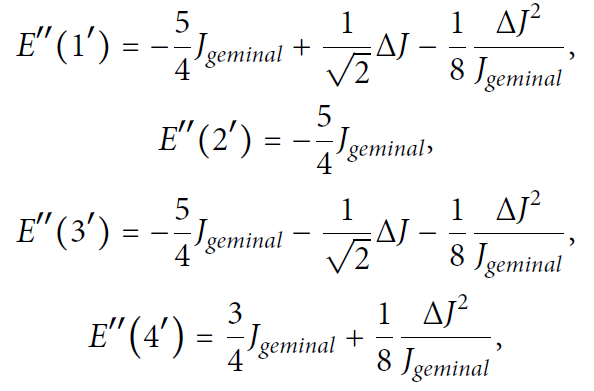

In [13]:
# Symbolic analysis along special directions in (S, D) coordinates

if "formulas_2d" not in globals():
    raise RuntimeError("Run the symbolic extraction cell before evaluating asymptotics.")

# Must match symbols created by sp.sympify() — no assumptions
S_sym, D_sym = sp.symbols('S D')

print("Analysis of extracted formulas in (S, D) coordinates")
print("=" * 60)

# 1. Along D = 0 (diagonal: A = ±B, so S = 2A²)
print("\n1. Along D = 0  (diagonal |A| = |B|, S = 2A²):")
print("-" * 60)
for model_key, outputs in formulas_2d.items():
    for output_name, expr in outputs.items():
        sym_expr = sp.sympify(expr)
        diag_expr = sp.simplify(sym_expr.subs(D_sym, 0))
        series_diag = sp.series(diag_expr, S_sym, 0, 3)
        intercept = float(diag_expr.subs(S_sym, 0))
        print(f"{output_name}:")
        print(f"  lambda(S, D=0) = {diag_expr}")
        print(f"  Series:     {series_diag}")
        print(f"  lambda(0, 0)  = {intercept:.6f}")
        print()

# 2. Along D = S (B = 0, only A varies: S = A², D = A²)
print("\n2. Along D = S  (B = 0, S = A²):")
print("-" * 60)
for model_key, outputs in formulas_2d.items():
    for output_name, expr in outputs.items():
        sym_expr = sp.sympify(expr)
        b0_expr = sp.simplify(sym_expr.subs(D_sym, S_sym))
        series_b0 = sp.series(b0_expr, S_sym, 0, 3)
        print(f"{output_name}:")
        print(f"  lambda(S, D=S) = {b0_expr}")
        print(f"  Series:     {series_b0}")
        print()

# 3. Along D = -S (A = 0, only B varies: S = B², D = -B²)
print("\n3. Along D = -S  (A = 0, S = B²):")
print("-" * 60)
for model_key, outputs in formulas_2d.items():
    for output_name, expr in outputs.items():
        sym_expr = sp.sympify(expr)
        a0_expr = sp.simplify(sym_expr.subs(D_sym, -S_sym))
        series_a0 = sp.series(a0_expr, S_sym, 0, 3)
        print(f"{output_name}:")
        print(f"  lambda(S, D=-S) = {a0_expr}")
        print(f"  Series:      {series_a0}")
        print()

# 4. Check symmetry: eigenvalues should depend on D² (not on sign of D)
print("\n4. D-parity check (eigenvalues should be even in D):")
print("-" * 60)
for model_key, outputs in formulas_2d.items():
    for output_name, expr in outputs.items():
        sym_expr = sp.sympify(expr)
        diff = sp.simplify(sym_expr.subs(D_sym, D_sym) - sym_expr.subs(D_sym, -D_sym))
        print(f"  {output_name}: f(S,D) - f(S,-D) = {diff}")
        if diff == 0:
            print(f"    -> Even in D (depends only on D^2)")
        else:
            print(f"    -> Odd terms present (KAN artifact)")

Analysis of extracted formulas in (S, D) coordinates

1. Along D = 0  (diagonal |A| = |B|, S = 2A²):
------------------------------------------------------------
eigenval_1:
  lambda(S, D=0) = 0.019*S**2 - 0.327*S - 1.453
  Series:     0.019*S**2 - 0.327*S - 1.453
  lambda(0, 0)  = -1.453000

eigenval_2:
  lambda(S, D=0) = 0.004*S**2 - 0.009*S - 1.274
  Series:     0.004*S**2 - 0.009*S - 1.274
  lambda(0, 0)  = -1.274000

eigenval_3:
  lambda(S, D=0) = -0.021*S**2 + 0.206*S - 1.021
  Series:     -0.021*S**2 + 0.206*S - 1.021
  lambda(0, 0)  = -1.021000

eigenval_4:
  lambda(S, D=0) = -0.002*S**2 + 0.127*S + 0.75
  Series:     -0.002*S**2 + 0.127*S + 0.75
  lambda(0, 0)  = 0.750000


2. Along D = S  (B = 0, S = A²):
------------------------------------------------------------
eigenval_1:
  lambda(S, D=S) = 0.024*S**2 - 0.327*S - 1.453
  Series:     0.024*S**2 - 0.327*S - 1.453

eigenval_2:
  lambda(S, D=S) = -0.011*S**2 - 0.009*S - 1.274
  Series:     -0.011*S**2 - 0.009*S - 1.274

eige

# Summary

This notebook successfully:

1. **Generated 2D dataset** using `ham_reduced_symmetric(Jintra, Jintra, Jintra, DeltaJAM, DeltaJMX, 0)` with parameters A and B
2. **Applied coordinate transformation** $S = A^2 + B^2$, $D = A^2 - B^2$, motivated by the analytic quartic structure
3. **Visualized eigenvalue surfaces** in both original $(A, B)$ and new $(S, D)$ coordinates
4. **Trained a KAN model** with inputs $(S, D)$ to predict 4 normalized eigenvalues
5. **Compared prediction surfaces** in both coordinate systems with error analysis
6. **Extracted symbolic formulas** $\lambda_i(S, D)$ showing the mathematical relationships in the natural coordinates
7. **Analyzed special directions**: $D=0$ (diagonal $|A|=|B|$), $D=S$ ($B=0$), $D=-S$ ($A=0$)
8. **Checked D-parity**: eigenvalues should analytically depend on $D^2$, not $D$

The coordinate transformation to $(S, D)$ is natural because the depressed quartic coefficients are:
- $p = -(S+3)/2$, $q = -1$, $r = D^2/16 + S/8 - 3/16$

so eigenvalues are truly functions of $S$ and $D^2$ only.

Generating 2D dataset: 100%|██████████| 5000/5000 [00:00<00:00, 54380.66it/s]


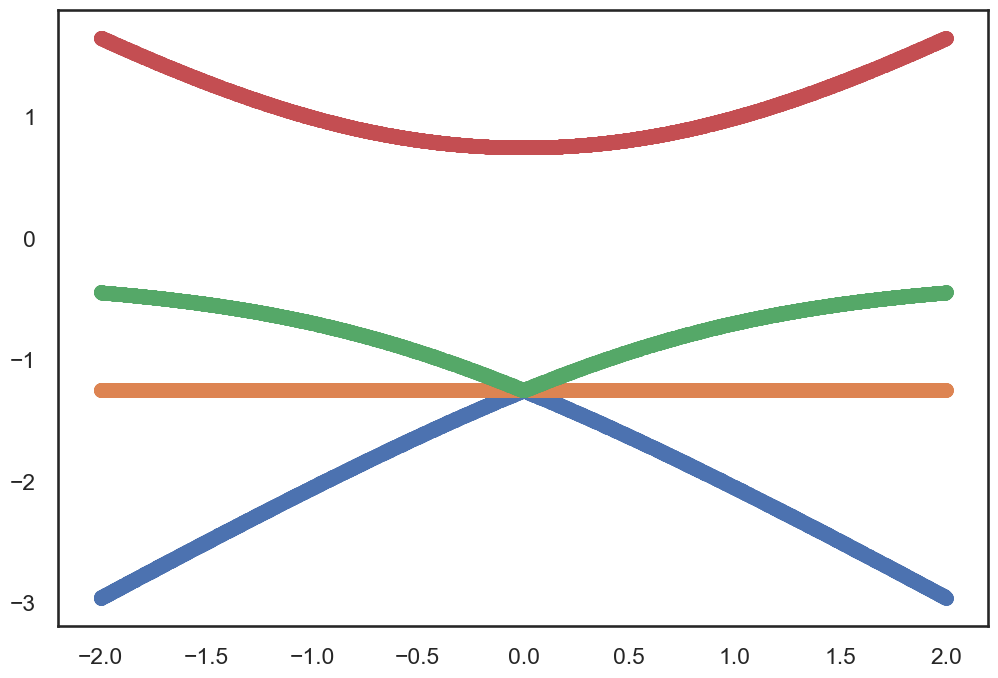

In [14]:
def generate_2d_normalized_dataset_diag(n_samples=5000, 
                                 deltajam_ratio_range=(-2.0, 2.0), 
                                 deltajmx_ratio_range=(-2.0, 2.0)):
    """
    Generate normalized 2D dataset using ham_reduced_symmetric.
    
    Directly generates ratios (DeltaJAM/Jintra, DeltaJMX/Jintra) uniformly,
    then calls ham_reduced_symmetric(1, 1, 1, ratio1, ratio2, 0).
    
    Parameters:
    - deltajam_ratio_range: Range for DeltaJAM/Jintra ratio
    - deltajmx_ratio_range: Range for DeltaJMX/Jintra ratio
    
    Returns normalized inputs (DeltaJAM/Jintra, DeltaJMX/Jintra) and normalized eigenvalues
    """
    
    # Generate random ratios directly (uniformly distributed)
    np.random.seed(42)  # For reproducibility
    deltajam_ratios = np.random.uniform(deltajam_ratio_range[0], deltajam_ratio_range[1], n_samples)
    deltajmx_ratios = deltajam_ratios
    #deltajmx_ratios = np.random.uniform(deltajmx_ratio_range[0], deltajmx_ratio_range[1], n_samples)
    
    # Initialize output arrays
    inputs_normalized = np.zeros((n_samples, 2))
    eigenvals_normalized = np.zeros((n_samples, 4))  # 4x4 Hamiltonian has 4 eigenvalues
    
    successful_samples = 0
    
    for i in tqdm(range(n_samples), desc="Generating 2D dataset"):
        try:
            # Use ratios directly
            deltajam_ratio = deltajam_ratios[i]
            deltajmx_ratio = deltajmx_ratios[i]
            
            # Create Hamiltonian: ham_reduced_symmetric(JAA, JMM, JXX, dJAM, dJMX, dJAX)
            # We use: JAA=JMM=JXX=1 (normalized), dJAM=deltajam_ratio, dJMX=deltajmx_ratio, dJAX=0
            H = ham_reduced_symmetric(1.0, 1.0, 1.0, deltajam_ratio, deltajmx_ratio, 0.0)
            
            # Calculate eigenvalues (already normalized since Jintra=1)
            eigenvals, _ = eigh(H)
            eigenvals = sort_eigenvalues_with_flip(eigenvals, ratio_value=deltajam_ratio*0+1)
            # Store inputs (ratios)
            inputs_normalized[successful_samples, 0] = deltajam_ratio
            inputs_normalized[successful_samples, 1] = deltajmx_ratio
            
            # Store eigenvalues (already normalized)
            eigenvals_normalized[successful_samples, :] = eigenvals
            
            successful_samples += 1
            
        except Exception as e:
            continue
    
    # Trim arrays to successful samples
    inputs_final = inputs_normalized[:successful_samples]
    eigenvals_final = eigenvals_normalized[:successful_samples]
    
    return inputs_final, eigenvals_final
dataset=generate_2d_normalized_dataset_diag()
plt.scatter(dataset[0][:,0], dataset[1][:,0])
plt.scatter(dataset[0][:,0], dataset[1][:,1])
plt.scatter(dataset[0][:,0], dataset[1][:,2])
plt.scatter(dataset[0][:,0], dataset[1][:,3])